<a href="https://colab.research.google.com/github/danielbrodev/computer_vision/blob/main/menu_detector_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
print("Menu Detector!")

Menu Detector!


#  Menu detector loyihasi bu taomlar rasmlari orqali train qilib malum taomlarni taniydigan model

In [ ]:
# -------------------------
# Import Libraries
# -------------------------
from google.colab import drive
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torchvision.models import mobilenet_v2

from PIL import Image, UnidentifiedImageError
from torch.utils.data import Dataset, DataLoader
import os
import numpy as np

In [ ]:
drive.mount('/content/drive') # drive ga ulanamiz

Mounted at /content/drive


In [ ]:
# Define dataset path
DATASET_PATH = '/content/drive/MyDrive/food-dataset'


CUSTOM_CLASS_MAPPING = {
    'hamburger': 'hamburger',
    'hot_dog': 'hot_dog',
    'chocolate_cake': 'dessert', # label grouping  |  class consolidation
    'kebab': 'kebab',
    'cheesecake': 'dessert',
    'pilaf': 'pilaf',
    'ice_cream': 'dessert'     # label grouping  |  class consolidation
}





CLASSES = ['hamburger', 'dessert', 'hot_dog', 'kebab', 'pilaf' ]
CLASS_TO_INDEX = {c: i for i, c in enumerate(CLASSES)}
NUM_CLASSES = len(CLASSES)

print(f'Classes: {CLASSES}')
print(f'Class to index: {CLASS_TO_INDEX}')
print(f'Number of classes: {NUM_CLASSES}')

# bu bizning ishlarimiz ketmaketligini belgilaydi
transform = transforms.Compose([
    transforms.Resize((224, 224)) , # bu rasmlarimiz sizeni o'zgartiradi
    transforms.ToTensor(), # tensorga o'giramiz(raqamlarga)
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
# Tensorga o'girgach u flot korinishiga otadi 0.0 ~ 1.0
# H, W, C => C, H, W  | => channel : RGB
# Normalize => hamma channellarni qayta sozlab beradi
# Normalize : pixel = (pixel-mean)/std



print("transform:", transform)

Classes: ['hamburger', 'dessert', 'hot_dog', 'kebab', 'pilaf']
Class to index: {'hamburger': 0, 'dessert': 1, 'hot_dog': 2, 'kebab': 3, 'pilaf': 4}
Number of classes: 5
transform: Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


In [ ]:
# -------------------------
# Custom Dataset Class
# -------------------------

class FoodDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform
# umumiy filelarni o'qish vaqtida data uzunligini olib beradi
    def __len__(self):
        print('images_length', len(self.images))
        return len(self.images)
#
    def __getitem__(self, idx):
        img_path = self.images[idx]
        print('image_path', img_path)

        label = self.labels[idx]
        print('label', label)
# agar rasmda RGB bolmasa convert qilamiz
        try:
            image = Image.open(img_path).convert('RGB')
        except (UnidentifiedImageError, OSError):
            print(f"Skipping broken image: {img_path}") # rasm filelarda kamchilik bolsa skip qilish
            return self.__getitem__((idx + 1) % len(self.images))

        if self.transform:
            image = self.transform(image)

        return image, label

In [ ]:
# -------------------------
# Gather and Split Data
# -------------------------

all_images = [] # created empty list

for original_class, mapped_class in CUSTOM_CLASS_MAPPING.items():
    class_path = os.path.join(DATASET_PATH, original_class)  # /content/drive/MyDrive/food-dataset/hamburber
    print('class_path:', class_path)

    if not os.path.exists(class_path):
        print(f"Warning: {class_path} not found")
        continue

    for img in os.listdir(class_path):
        if img.endswith(('.jpg', '.jpeg', '.png')):
            full_path = os.path.join(class_path, img) # /content/drive/MyDrive/food-dataset/hamburber/233.jpg
            all_images.append((full_path, CLASS_TO_INDEX[mapped_class])) # Changed CLASS_TO_IDX to CLASS_TO_INDEX

np.random.shuffle(all_images) #random aralashtiradi

split = int(0.8 * len(all_images))
train_data = all_images[:split] # 1000m | 800 train_data | 200 val_data
val_data = all_images[split:]

train_images, train_labels = zip(*train_data)
val_images, val_labels = zip(*val_data)

# print('all_images:', all_images)

dataset = FoodDataset(train_images, train_labels)
print(len(dataset))
img, lbl = dataset[0]

class_path: /content/drive/MyDrive/food-dataset/hamburger
class_path: /content/drive/MyDrive/food-dataset/hot_dog
class_path: /content/drive/MyDrive/food-dataset/chocolate_cake
class_path: /content/drive/MyDrive/food-dataset/kebab
class_path: /content/drive/MyDrive/food-dataset/cheesecake
class_path: /content/drive/MyDrive/food-dataset/pilaf
class_path: /content/drive/MyDrive/food-dataset/ice_cream
images_length 260
260
image_path /content/drive/MyDrive/food-dataset/hot_dog/Image_50.jpg
label 2


In [ ]:
train_dataset = FoodDataset(train_images, train_labels, transform=transform)
val_dataset = FoodDataset(val_images, val_labels, transform=transform)

In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2
)  # thread | parallel loading for speed

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

images_length 260
images_length 260


In [ ]:
# pretrained model

model = mobilenet_v2(weights="IMAGENET1K_V1")  # pretrained model | lightweight | CNN | 1000 class | million

model.classifier[1] = nn.Linear(
    model.classifier[1].in_features,
    NUM_CLASSES
)  # fine-tuning | backbone | model layer freeze

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 77.6MB/s]


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device', device)

model = model.to(device)

device cpu


In [ ]:
criterion = nn.CrossEntropyLoss()  # Loss Function | '70%' burger, '30%' pilaf

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)  # weight

torch.backends.cudnn.benchmark = True  # Benchmark Setting | Trick | 10%-20%

In [ ]:
# -------------------------
# Training Loop
# -------------------------

NUM_EPOCHS = 2
best_accuracy = 0.0

for epoch in range(NUM_EPOCHS):
    model.train()  # train mode
    running_loss = 0.0

    for images, labels in train_loader:  # Forward and Backward(Backpropagation)
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()  # zero the gradient

        outputs = model(images)  # Forward Pass | Dog | 5 Classes
        loss = criterion(outputs, labels)  # Calculate Loss

        loss.backward()
        optimizer.step()  # Adam optimizer

        running_loss += loss.item()  # Track Loss

    # Validation
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = 100 * correct / total  # Calculate Validation Accuracy

    print(
        f"Epoch [{epoch+1}/{NUM_EPOCHS}] "
        f"Loss: {running_loss/len(train_loader):.4f}, "
        f"Val Accuracy: {val_acc:.2f}%"
    )

    if val_acc > best_accuracy:
        best_accuracy = val_acc
        torch.save(model.state_dict(), "/content/menu_detector.pth")
        print("Saved new best model!")


image_path /content/drive/MyDrive/food-dataset/hot_dog/Image_65.jpeg
labelimage_path  2/content/drive/MyDrive/food-dataset/hamburger/Image_10.jpg

label 0
image_path /content/drive/MyDrive/food-dataset/chocolate_cake/Image_43.jpg
label 1
images_length 260
images_length 260
image_path /content/drive/MyDrive/food-dataset/chocolate_cake/Image_3.jpg
label 1
image_path /content/drive/MyDrive/food-dataset/chocolate_cake/Image_46.jpg
label 1
image_path /content/drive/MyDrive/food-dataset/hot_dog/Image_50.jpg
label 2
image_path /content/drive/MyDrive/food-dataset/ice_cream/Image_17.jpg
label 1
image_path /content/drive/MyDrive/food-dataset/hot_dog/Image_8.jpg
image_pathlabel  2/content/drive/MyDrive/food-dataset/ice_cream/Image_28.jpg

label 1
image_path image_path /content/drive/MyDrive/food-dataset/hot_dog/Image_59.jpeg/content/drive/MyDrive/food-dataset/pilaf/Image_69.jpg
label
 label2
 4
image_path /content/drive/MyDrive/food-dataset/hamburger/Image_23.jpg
labelimage_path  /content/drive/M

device: cpu
Upload one or more images of your food:


Saving Image_1.jpg to Image_1.jpg


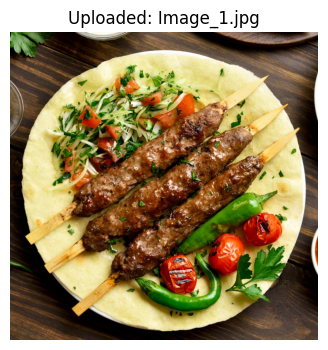

Prediction:
 ✅ kebab: 100.00%
 ✅ pilaf: 0.00%
 ✅ hot_dog: 0.00%
 ✅ dessert: 0.00%


In [ ]:
# ----------------------------------------
# Required Imports
# ----------------------------------------
import torch
import torchvision.transforms as transforms
from torchvision.models import mobilenet_v2
from PIL import Image
from google.colab import files
import io
import matplotlib.pyplot as plt


# ----------------------------------------
# Define Semantic Classes
# ----------------------------------------
CLASSES = ['hamburger', 'hot_dog', 'dessert', 'kebab', 'pilaf']  # Must match training order
NUM_CLASSES = len(CLASSES)
CLASS_TO_IDX = {cls: i for i, cls in enumerate(CLASSES)}


# ----------------------------------------
# Transform for Uploaded Images (no augmentation!)
# ----------------------------------------
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


# ----------------------------------------
# Load Model
# ----------------------------------------

model = mobilenet_v2(weights=None)
model.classifier[1] = torch.nn.Linear(model.classifier[1].in_features, NUM_CLASSES)
model.load_state_dict(torch.load('/content/menu_detector.pth', map_location='cpu'))

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

model = model.to(device)
model.eval()


# ----------------------------------------
# Upload & Predict
# ----------------------------------------
print("Upload one or more images of your food:")
uploaded = files.upload()

for image_name in uploaded.keys():
    image = Image.open(io.BytesIO(uploaded[image_name])).convert('RGB')

    # Display image
    plt.figure(figsize=(4, 4))
    plt.imshow(image)
    plt.axis('off')
    plt.title(f'Uploaded: {image_name}')
    plt.show()

# Predict
image_tensor = transform(image).unsqueeze(0).to(device)

with torch.no_grad():
    output = model(image_tensor)
    probs = torch.softmax(output, dim=1)[0]
    topk = torch.topk(probs, 4)

print("Prediction:")
for i in range(topk.indices.size(0)):
    label = CLASSES[topk.indices[i]]
    confidence = topk.values[i].item() * 100
    print(f" ✅ {label}: {confidence:.2f}%")